In [1]:
# In[1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import traceback
import glob

# --- Global Configuration & Setup ---
# This ensures all paths are correct, no matter where you run the notebook from.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Project Root set to: {PROJECT_ROOT}")

# Set a professional plot style
sns.set_theme(style="whitegrid", context="talk")

Project Root set to: D:\Master thesis\improved-version\master-thesis-trajectory-data-augmentation


In [2]:
# In[2]:
class TrajectoryAnalyzer:
    """
    A class to encapsulate the entire analysis pipeline for a single
    dataset-strategy-seed combination.
    """
    # ... (The __init__, _find_optimal_params_and_load_data, _prepare_data_for_ml,
    #      and _train_models_and_get_scores methods are all the same. No changes needed there.)

    def __init__(self, dataset_name, strategy_name, seed):
        print("="*80)
        print(f"INITIALIZING ANALYZER FOR: Dataset='{dataset_name}', Strategy='{strategy_name}', Seed={seed}")
        print("="*80)

        self.dataset_name = dataset_name
        self.strategy_name = strategy_name
        self.seed = seed

        self._find_optimal_params_and_load_data()
        self._prepare_data_for_ml()
        self._train_models_and_get_scores()

    def _find_optimal_params_and_load_data(self):
        """Finds the best hyperparameters and loads all necessary feature files."""
        print("\n[1/4] Finding optimal parameters and loading data...")

        history_dir = os.path.join(PROJECT_ROOT, 'data', 'output', 'optimization', 'history')

        best_suffix_for_strategy = self._get_best_suffix_for_strategy(history_dir)

        base_path = os.path.join(PROJECT_ROOT, 'data', 'augmented', self.dataset_name, str(self.seed))
        path_train_orig_feats = os.path.join(base_path, f"train_seed_{self.seed}_pts_trajectory_features.feather")
        path_train_aug_feats = os.path.join(base_path, f"train_seed_{self.seed}_pts_trajectory_features_merged_{self.strategy_name}{best_suffix_for_strategy}.feather")
        path_test_feats = os.path.join(base_path, f"test_seed_{self.seed}_pts_trajectory_features.feather")

        self.df_train_orig = pd.read_feather(path_train_orig_feats)
        self.df_train_aug = pd.read_feather(path_train_aug_feats)
        self.df_test = pd.read_feather(path_test_feats)

        self.tids_with_augs = self.df_train_aug[~self.df_train_aug['tid'].isin(self.df_train_orig['tid'])]['tid'].apply(lambda x: x.split('_')[0]).unique()
        print(f"✓ Success: Data loaded. Found {len(self.tids_with_augs)} trajectories selected for augmentation.")

    def _get_best_suffix_for_strategy(self, history_dir):
        """Scans Optuna files to find the best run for our specific strategy."""
        search_pattern = os.path.join(history_dir, f'{self.dataset_name}_p*.csv')
        param_regex = re.compile(r'(_p\d+_n\d+_pp\d+)\.csv$')

        best_score = -1
        best_suffix = ""

        for f in glob.glob(search_pattern):
            match = param_regex.search(f)
            if not match: continue

            df = pd.read_csv(f)
            df['strategy'] = df['feature_type'].apply(lambda ft: ft.split('merged_')[-1].split('_p')[0] if 'merged' in str(ft) else 'baseline')

            strategy_group = df[df['strategy'] == self.strategy_name]
            if not strategy_group.empty:
                current_score = strategy_group['score'].mean()
                if current_score > best_score:
                    best_score = current_score
                    best_suffix = match.group(1)

        if not best_suffix:
            raise ValueError(f"Could not find any Optuna results for strategy '{self.strategy_name}'")

        print(f"✓ Found best suffix for '{self.strategy_name}': {best_suffix} (Score: {best_score:.4f})")
        return best_suffix

    def _prepare_data_for_ml(self):
        """Handles column alignment, scaling, and label encoding."""
        print("\n[2/4] Preparing data for machine learning...")
        common_cols = sorted(list(set(self.df_train_orig.columns) & set(self.df_test.columns) - {'tid', 'label'}))
        self.common_cols = common_cols

        X_train_orig, y_train_orig = self.df_train_orig[common_cols].fillna(0), self.df_train_orig['label']
        X_train_aug, y_train_aug = self.df_train_aug[common_cols].fillna(0), self.df_train_aug['label']
        X_test, y_test = self.df_test[common_cols].fillna(0), self.df_test['label']

        self.le = LabelEncoder()
        self.y_train_orig_enc = self.le.fit_transform(y_train_orig)
        self.y_train_aug_enc = self.le.transform(y_train_aug)
        self.y_test_enc = self.le.transform(y_test)
        self.class_names = self.le.classes_

        scaler = StandardScaler()
        self.X_train_orig_scaled = scaler.fit_transform(X_train_orig)
        self.X_train_aug_scaled = scaler.transform(X_train_aug)
        self.X_test_scaled = scaler.transform(X_test)
        print("✓ Success: Data prepared.")

    def _train_models_and_get_scores(self):
        """Trains models on original and augmented data and calculates F1 scores."""
        print("\n[3/4] Training models and calculating scores...")
        self.pca = PCA(n_components=2, random_state=42)
        X_train_orig_pca = self.pca.fit_transform(self.X_train_orig_scaled)
        X_train_aug_pca = self.pca.transform(self.X_train_aug_scaled)
        X_test_pca = self.pca.transform(self.X_test_scaled)

        self.model_orig = LogisticRegression(random_state=42, C=0.1).fit(X_train_orig_pca, self.y_train_orig_enc)
        self.model_aug = LogisticRegression(random_state=42, C=0.1).fit(X_train_aug_pca, self.y_train_aug_enc)

        y_pred_orig = self.model_orig.predict(X_test_pca)
        y_pred_aug = self.model_aug.predict(X_test_pca)
        self.f1_orig = f1_score(self.y_test_enc, y_pred_orig, average='weighted', zero_division=0)
        self.f1_aug = f1_score(self.y_test_enc, y_pred_aug, average='weighted', zero_division=0)
        self.f1_improvement = ((self.f1_aug - self.f1_orig) / self.f1_orig) * 100 if self.f1_orig > 0 else 0
        print("✓ Success: Models trained.")


    def generate_master_plot(self, save_path=None):
        """
        Generates the final, publication-quality 'Master Plot', faithfully
        reproducing the logic from the original, working notebook script.
        This version is robust to multi-class datasets and has the correct styling.
        """
        print("\n[4/4] Generating master visualization...")

        plt.style.use('dark_background')

        # --- 1. Prepare DataFrames for Plotting (using the original, correct logic) ---
        X_train_orig_pca = self.pca.transform(self.X_train_orig_scaled)
        X_train_aug_pca = self.pca.transform(self.X_train_aug_scaled)

        # Ground-truth for original points
        df_train_orig_pca = pd.DataFrame(X_train_orig_pca, columns=['pca1', 'pca2'])
        df_train_orig_pca['tid'] = self.df_train_orig['tid'].values
        df_train_orig_pca['label_enc'] = self.y_train_orig_enc
        df_train_orig_pca['type'] = 'Original (Not Selected)'
        df_train_orig_pca.loc[df_train_orig_pca['tid'].isin(self.tids_with_augs), 'type'] = 'Selected Original'

        # Correctly isolate ONLY the new, synthetic points
        df_train_aug_full_pca = pd.DataFrame(X_train_aug_pca, columns=['pca1', 'pca2'])
        df_train_aug_full_pca['tid'] = self.df_train_aug['tid'].values

        # --- THE FIX: Define and use 'df_augmented_only_pca' consistently ---
        df_augmented_only_pca = df_train_aug_full_pca[~df_train_aug_full_pca['tid'].isin(df_train_orig_pca['tid'])].copy()

        if not df_augmented_only_pca.empty:
            aug_labels = self.df_train_aug[self.df_train_aug['tid'].isin(df_augmented_only_pca['tid'])]['label']
            df_augmented_only_pca['label_enc'] = self.le.transform(aug_labels)
            df_augmented_only_pca['parent_tid'] = df_augmented_only_pca['tid'].apply(lambda x: x.split('_')[0])
            df_augmented_only_pca['type'] = 'Augmented'

        df_master_after = pd.concat([df_train_orig_pca, df_augmented_only_pca])

        # --- 2. Dynamic Color Palette ---
        n_classes = len(self.class_names)
        class_colors = sns.color_palette("tab10", n_colors=n_classes)
        cmap_explicit = ListedColormap(class_colors)

        # --- 3. Create the Plot ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 11))

        q_low_x, q_high_x = df_master_after['pca1'].quantile(0.01), df_master_after['pca1'].quantile(0.99)
        q_low_y, q_high_y = df_master_after['pca2'].quantile(0.01), df_master_after['pca2'].quantile(0.99)
        x_margin = (q_high_x - q_low_x) * 0.1; y_margin = (q_high_y - q_low_y) * 0.1
        xx, yy = np.meshgrid(np.arange(q_low_x - x_margin, q_high_x + x_margin, 0.05),
                             np.arange(q_low_y - y_margin, q_high_y + y_margin, 0.05))

        # --- PLOT 1: BEFORE ---
        ax1.set_title(f"Before Augmentation (Original Data)\nModel F1-Score: {self.f1_orig:.4f}", fontsize=18)
        Z_orig = self.model_orig.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax1.contourf(xx, yy, Z_orig, alpha=0.2, cmap=cmap_explicit)
        not_selected = df_train_orig_pca[df_train_orig_pca['type'] == 'Original (Not Selected)']
        selected = df_train_orig_pca[df_train_orig_pca['type'] == 'Selected Original']
        ax1.scatter(not_selected['pca1'], not_selected['pca2'], s=50, facecolors='none', edgecolors=[class_colors[i] for i in not_selected['label_enc']], alpha=0.6, linewidth=1.5)
        ax1.scatter(selected['pca1'], selected['pca2'], s=150, marker='*', c=[class_colors[i] for i in selected['label_enc']], edgecolors='yellow', linewidth=1.5)

        # --- PLOT 2: AFTER ---
        ax2.set_title(f"After Augmentation\nModel F1-Score: {self.f1_aug:.4f}", fontsize=18)
        Z_aug = self.model_aug.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax2.contourf(xx, yy, Z_aug, alpha=0.2, cmap=cmap_explicit)
        ax2.scatter(not_selected['pca1'], not_selected['pca2'], s=50, facecolors='none', edgecolors=[class_colors[i] for i in not_selected['label_enc']], alpha=0.6, linewidth=1.5)
        ax2.scatter(selected['pca1'], selected['pca2'], s=150, marker='*', c=[class_colors[i] for i in selected['label_enc']], edgecolors='yellow', linewidth=1.5)

        # --- THE FIX: Use 'df_augmented_only_pca' consistently ---
        if not df_augmented_only_pca.empty:
            ax2.scatter(df_augmented_only_pca['pca1'], df_augmented_only_pca['pca2'], s=60, marker='P', c=[class_colors[i] for i in df_augmented_only_pca['label_enc']], edgecolors='k', linewidth=1)

        if not selected.empty and not df_augmented_only_pca.empty:
            parents_pca = selected.set_index('tid')
            for _, child in df_augmented_only_pca.iterrows():
                if child['parent_tid'] in parents_pca.index:
                    parent = parents_pca.loc[child['parent_tid']]
                    ax2.plot([parent['pca1'], child['pca1']], [parent['pca2'], child['pca2']], color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

        for ax in [ax1, ax2]:
            ax.set_xlabel("Principal Component 1"); ax.set_ylabel("Principal Component 2")
            ax.set_xlim(xx.min(), xx.max()); ax.set_ylim(yy.min(), yy.max())

        # --- 4. Dynamic Legend ---
        legend_elements = []
        for i, class_name in enumerate(self.class_names):
            legend_elements.extend([
                Line2D([0], [0], marker='o', label=f"Class '{class_name}' (Original)", markerfacecolor='none', markeredgecolor=class_colors[i], markersize=10, linestyle='None'),
                Line2D([0], [0], marker='*', label=f"Class '{class_name}' (Selected)", markerfacecolor=class_colors[i], markeredgecolor='yellow', markersize=15, linestyle='None'),
                Line2D([0], [0], marker='P', label=f"Class '{class_name}' (Augmented)", markerfacecolor=class_colors[i], markeredgecolor='k', markersize=10, linestyle='None'),
            ])
        legend_elements.extend([
            Patch(facecolor=color, alpha=0.4, edgecolor='k', label=f"Decision Region for '{name}'")
            for name, color in zip(self.class_names, class_colors)
        ])
        fig.legend(handles=legend_elements, loc='lower center', ncol=max(n_classes, 3), bbox_to_anchor=(0.5, -0.07), fontsize=14)

        # --- 5. The Title ---
        title_string = (f"Visual Analysis of Augmentation Strategy\n"
                        f"Dataset: {self.dataset_name.title()} | Strategy: {self.strategy_name.title()} | Seed: {self.seed}\n"
                        f"Final F1-Score Improvement: {self.f1_improvement:+.2f}%")
        fig.suptitle(title_string, fontsize=24, y=1.03)
        plt.tight_layout(rect=[0, 0.05, 1, 1])

        if save_path:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
            plt.close(fig)
            print(f"✓ Success: Plot saved to {save_path}")
        else:
            plt.show()

        plt.style.use('default')

INITIALIZING ANALYZER FOR: Dataset='foxes', Strategy='uncertainty', Seed=1415

[1/4] Finding optimal parameters and loading data...
✓ Found best suffix for 'uncertainty': _p40_n5_pp40 (Score: 0.5065)
✓ Success: Data loaded. Found 20 trajectories selected for augmentation.

[2/4] Preparing data for machine learning...
✓ Success: Data prepared.

[3/4] Training models and calculating scores...
✓ Success: Models trained.

[4/4] Generating master visualization...


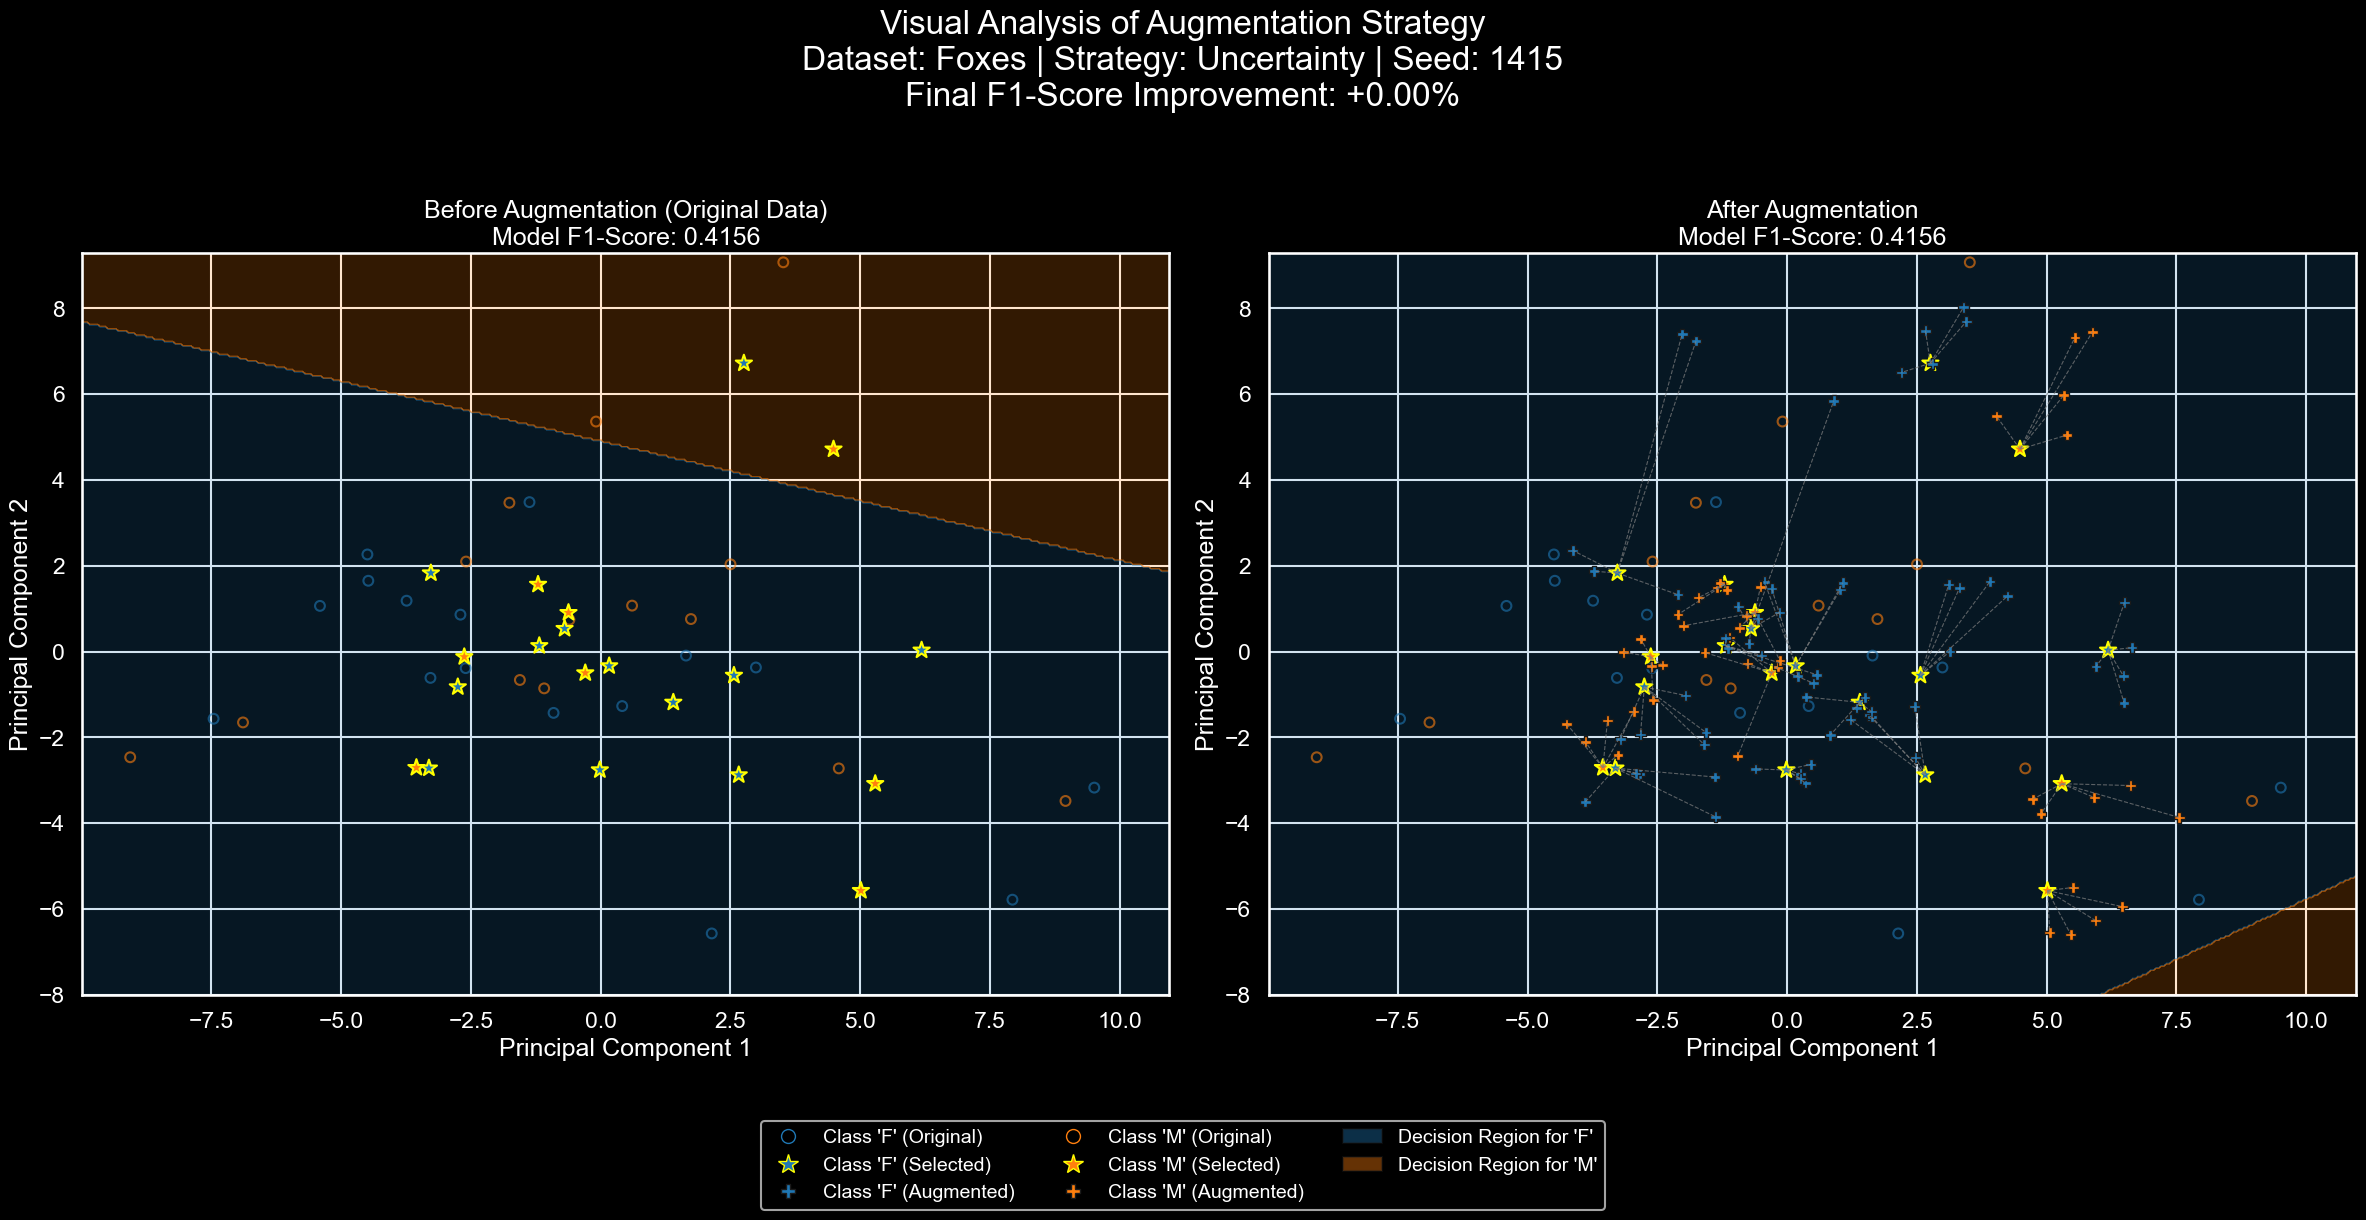

In [3]:
# In[3]:
# ===================================================================
# ==                     INTERACTIVE ANALYSIS                      ==
# ===================================================================
# --- Simply change these values to analyze a different scenario ---

CONFIG = {
    "dataset": 'foxes',        # Options: 'foxes', 'car_traffic', 'starkey', 'ais_subset'
    "strategy": 'uncertainty', # Options: 'outlierness', 'random', 'diversity', 'representativeness', 'uncertainty'
    "seed": 1415               # Options: Any seed from your PI_SEEDS list
}

# --- Then, run this cell to generate the full analysis plot ---
try:
    analyzer = TrajectoryAnalyzer(
        dataset_name=CONFIG["dataset"],
        strategy_name=CONFIG["strategy"],
        seed=CONFIG["seed"]
    )
    analyzer.generate_master_plot() # Call with no arguments to show the plot inline

except Exception as e:
    print("\n" + "!"*80)
    print("--- ANALYSIS FAILED ---")
    print(f"Error: {e}")
    print("\nIMPORTANT: This usually means you haven't run the main pipeline for this combination yet.")
    print(f"Please run 'python main.py --datasets {CONFIG['dataset']}' to generate the necessary files.")
    print("--- Full Traceback ---")
    traceback.print_exc()
    print("!"*80)

In [4]:
# In[4]:
# ===================================================================
# ==          BATCH MODE: GENERATE AND SAVE ALL IMAGES             ==
# ===================================================================
import traceback

# --- FIX: Define color variables for clean console output ---
try:
    import colorama
    colorama.init(autoreset=True)
    GREEN, RED, YELLOW, RESET = colorama.Fore.GREEN, colorama.Fore.RED, colorama.Fore.YELLOW, colorama.Style.RESET_ALL
except ImportError:
    print("Colorama not found. For colored output, run: pip install colorama")
    # If colorama is not found, define the variables as empty strings so the f-strings don't break.
    GREEN = RED = YELLOW = RESET = ""
# --- END OF FIX ---


# --- Configure your batch job here ---
DATASETS_TO_PROCESS = ['foxes', 'starkey', 'ais_subset', 'car_traffic']
STRATEGIES_TO_PROCESS = ['outlierness', 'random', 'diversity', 'representativeness', 'uncertainty']

# --- The full list of all 20 seeds ---
PI_SEEDS = [1415, 9265, 3589, 7932, 3846, 2643, 3832, 7950, 2884, 1971,
            6939, 9375, 1058, 2097, 4944, 5923, 781, 6406, 2862, 899]
SEEDS_TO_PROCESS = PI_SEEDS

# --- The correct output directory ---
BASE_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'output', 'analysis', 'visual_analysis')
# --- End of configuration ---

jobs = [{'dataset': d, 'strategy': s, 'seed': seed}
        for d in DATASETS_TO_PROCESS
        for s in STRATEGIES_TO_PROCESS
        for seed in SEEDS_TO_PROCESS]

print(f"Starting batch job. Total combinations to check: {len(jobs)}")
failed_jobs = []
skipped_count = 0
processed_count = 0

for i, job in enumerate(jobs):
    dataset, strategy, seed = job['dataset'], job['strategy'], job['seed']
    job_desc = f"JOB {i+1}/{len(jobs)}: {dataset}/{strategy}/{seed}"

    output_path = os.path.join(BASE_OUTPUT_DIR, dataset, str(seed), f"{strategy}.png")

    if os.path.exists(output_path):
        print(f"SKIPPING: Output already exists for {job_desc}")
        skipped_count += 1
        continue

    print("\n" + "-"*80)
    print(f"--- STARTING {job_desc} ---")

    try:
        analyzer = TrajectoryAnalyzer(dataset, strategy, seed)
        analyzer.generate_master_plot(save_path=output_path)
        processed_count += 1
    except FileNotFoundError as e:
        error_message = f"SKIPPING: Required data file not found. Please run the main pipeline. Details: {e}"
        print(f"{YELLOW}{error_message}{RESET}")
        failed_jobs.append({'job': job, 'error': "Data file not found"})
    except Exception as e:
        error_traceback = traceback.format_exc()
        error_message = f"FAILED with an unexpected error: {e}"

        print(f"{RED}{'!'*80}{RESET}")
        print(f"{RED}--- FATAL ERROR in job: {job_desc} ---{RESET}")
        print(f"{RED}{error_message}{RESET}")
        print("--- Full Traceback ---")
        print(error_traceback)
        print(f"{RED}{'!'*80}{RESET}")

        failed_jobs.append({'job': job, 'error': str(e)})

# --- Final Summary Report ---
print("\n\n" + "="*80)
print("BATCH PROCESSING COMPLETE!")
print(f"Summary: {processed_count} new images generated, {skipped_count} skipped, {len(failed_jobs)} failed.")
print(f"All generated images can be found in the '{BASE_OUTPUT_DIR}' folder.")

if failed_jobs:
    print("\n--- SUMMARY OF FAILED JOBS ---")
    for failure in failed_jobs:
        print(f"  - Job: {failure['job']} | Error: {failure['error']}")
else:
    print(f"\n{GREEN}✓✓✓ All jobs completed successfully or were already done! ✓✓✓{RESET}")

Starting batch job. Total combinations to check: 400

--------------------------------------------------------------------------------
--- STARTING JOB 1/400: foxes/outlierness/1415 ---
INITIALIZING ANALYZER FOR: Dataset='foxes', Strategy='outlierness', Seed=1415

[1/4] Finding optimal parameters and loading data...
✓ Found best suffix for 'outlierness': _p40_n3_pp40 (Score: 0.4877)
✓ Success: Data loaded. Found 20 trajectories selected for augmentation.

[2/4] Preparing data for machine learning...
✓ Success: Data prepared.

[3/4] Training models and calculating scores...
✓ Success: Models trained.

[4/4] Generating master visualization...
✓ Success: Plot saved to D:\Master thesis\improved-version\master-thesis-trajectory-data-augmentation\data\output\analysis\visual_analysis\foxes\1415\outlierness.png

--------------------------------------------------------------------------------
--- STARTING JOB 2/400: foxes/outlierness/9265 ---
INITIALIZING ANALYZER FOR: Dataset='foxes', Strategy